<a href="https://colab.research.google.com/github/Dipto1971/Statistical-Analysis-Data-Science/blob/main/Assignment/Assignment_01(2022_2_60_044).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Github: https://github.com/Dipto1971/Statistical-Analysis-Data-Science/tree/main/Assignment

# Loading a DataFrame from a Dataset

In [8]:
!gdown --id 1XnxWbFgcwFmbNY4mQAiTaMqL-aB8YGbl
url = 'education_data.csv'
df = pd.read_csv(url)
df.head()

'gdown' is not recognized as an internal or external command,
operable program or batch file.


FileNotFoundError: [Errno 2] No such file or directory: 'education_data.csv'

# Data Cleaning and Analysis

In [ ]:
# Check for Missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
print("Missing Data: ", missing_percentage)

# Theree's missing data in CGPA and Attendance_Percentage

Missing Data:  Student_ID                     0.00
Age                            0.00
Gender                         0.00
Department                     0.00
Year_of_Study                  0.00
CGPA                          10.01
Attendance_Percentage         10.24
Study_Hours_per_Week           0.00
Extracurricular_Activities     0.00
Part_Time_Job                  0.00
Satisfaction_Level             0.00
Scholarship                    0.00
Parental_Education_Level       0.00
Internet_Access                0.00
Family_Income                  0.00
dtype: float64


##Visualizing the missing Data

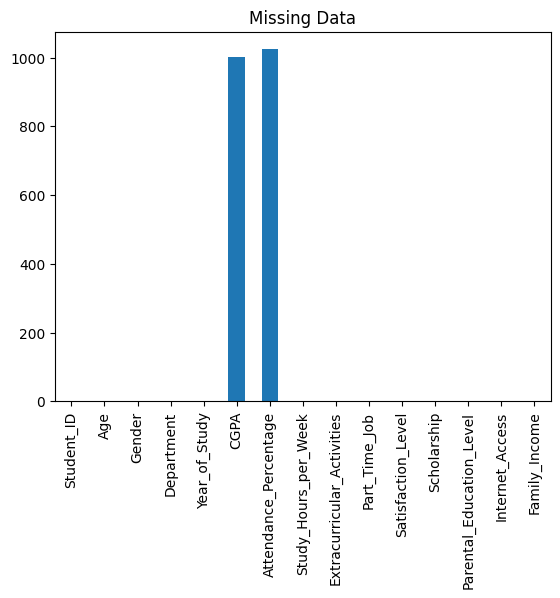

Mean of CGPA:  3.000502278030892
Mean of Attendance Percentage:  75.1243404634581


In [ ]:
# Visualize Missing data using historgram
missing_data.plot(kind='bar', title='Missing Data')
plt.show()

# Missing data in columns CGPA and Attendance Percentage. Determining the CGPA_mean and Attendance_Percentage_mean
CGPA_mean = df['CGPA'].mean()
Attendance_Percentage_mean = df['Attendance_Percentage'].mean()
print("Mean of CGPA: ", CGPA_mean)
print("Mean of Attendance Percentage: ", Attendance_Percentage_mean)

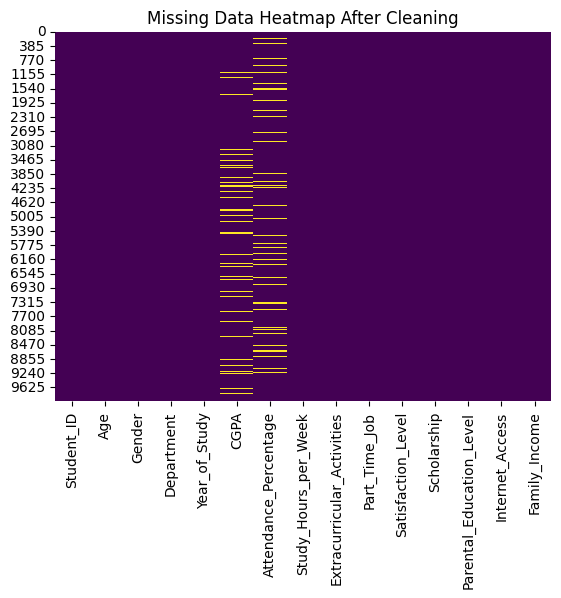

In [ ]:
# Visualize missing data before cleaning
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap After Cleaning')
plt.show()

###Handling missing Data (Replacing missing values of CGPA and Attendance Percentage Column with Mean)

In [ ]:
# Handling missing data: For only CGPA and Attendance_Percentage columns
df['CGPA'].fillna(df['CGPA'].mean(), inplace=True)
df['Attendance_Percentage'].fillna(df['Attendance_Percentage'].mean(), inplace=True)


<ipython-input-19-8e0dc258b3e5>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CGPA'].fillna(df['CGPA'].mean(), inplace=True)
<ipython-input-19-8e0dc258b3e5>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

##Confirming that there's no missing data in any column

In [ ]:
# Check for missing data after cleaning
missing_data_after = df.isnull().sum()
missing_percentage_after = (missing_data_after / len(df)) * 100
print("Missing Data After Cleaning:\n", missing_percentage_after)

# Show CGPA counts according to range
df['CGPA'].value_counts(bins=5).sort_index()

# There's CGPA values above 4
# CGPA's above 4
df[df['CGPA'] > 4]

Missing Data After Cleaning:
 Student_ID                    0.0
Age                           0.0
Gender                        0.0
Department                    0.0
Year_of_Study                 0.0
CGPA                          0.0
Attendance_Percentage         0.0
Study_Hours_per_Week          0.0
Extracurricular_Activities    0.0
Part_Time_Job                 0.0
Satisfaction_Level            0.0
Scholarship                   0.0
Parental_Education_Level      0.0
Internet_Access               0.0
Family_Income                 0.0
dtype: float64


,Student_ID,Age,Gender,Department,Year_of_Study,CGPA,Attendance_Percentage,Study_Hours_per_Week,Extracurricular_Activities,Part_Time_Job,Satisfaction_Level,Scholarship,Parental_Education_Level,Internet_Access,Family_Income
9,S0010,28,Non-binary,Chemistry,Third,4.15,99.36,16,Yes,No,Dissatisfied,No,Master's,Yes,Low
72,S0073,19,Male,Biology,Second,4.03,51.17,28,No,No,Neutral,Yes,Master's,Yes,Medium
257,S0258,21,Male,Biology,First,4.08,77.92,10,Yes,No,Very Dissatisfied,Yes,PhD,Yes,High
352,S0353,22,Male,Economics,Fourth,4.16,99.78,35,Yes,No,Satisfied,Yes,Master's,No,High
356,S0357,22,Male,Economics,Fourth,4.07,50.59,10,No,No,Neutral,No,High School,Yes,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9517,S9518,21,Male,Computer Science,First,4.04,76.47,8,Yes,No,Neutral,No,PhD,No,Low
9588,S9589,27,Male,Economics,Second,4.11,72.36,39,No,Yes,Satisfied,Yes,PhD,Yes,Low
9699,S9700,19,Male,Mathematics,Third,4.15,65.57,25,No,Yes,Neutral,Yes,Master's,Yes,High
9908,S9909,25,Male,Chemistry,First,4.02,69.64,37,No,No,Very Satisfied,Yes,Master's,Yes,Medium


# Outlier Detection

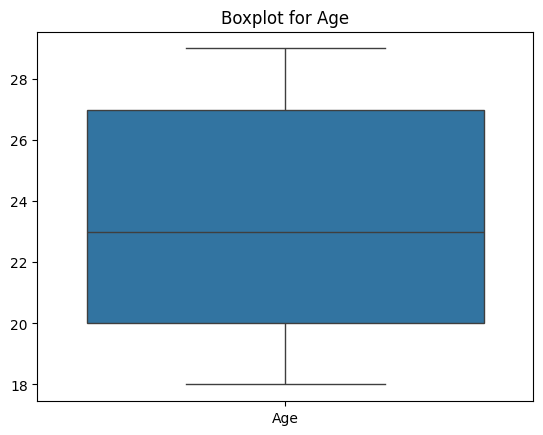

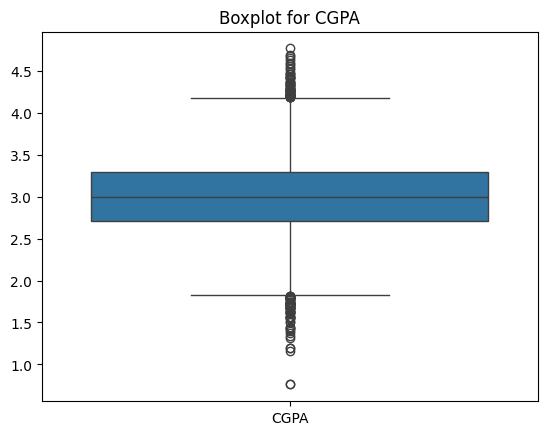

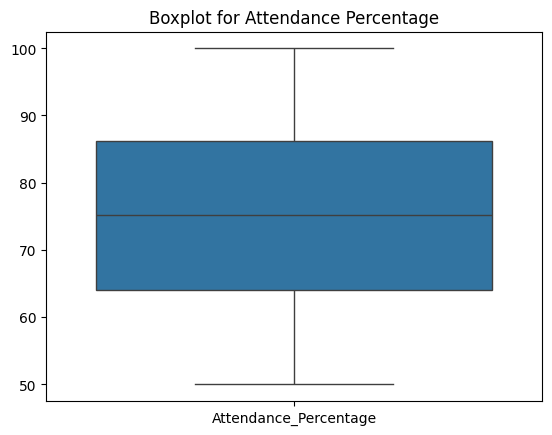

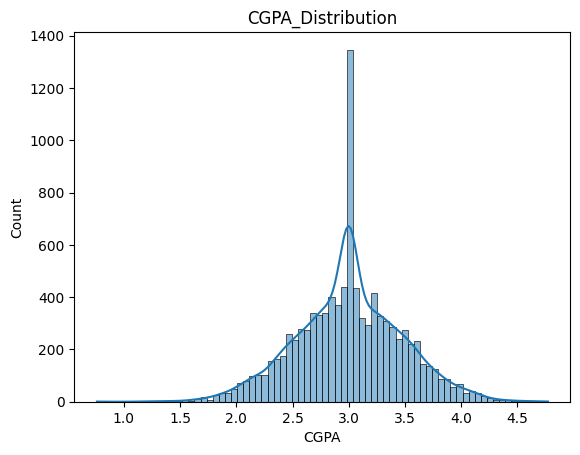

In [ ]:
# Boxplots for detecting outliers
sns.boxplot(data=df[['Age']])
plt.title('Boxplot for Age')
plt.show()

sns.boxplot(data=df[['CGPA']])
plt.title('Boxplot for CGPA')
plt.show()

sns.boxplot(data=df[['Attendance_Percentage']])
plt.title('Boxplot for Attendance Percentage')
plt.show()

# Analyzing the boxplot: Outliers detected only in CGPA, also anomalies (CGPA greater than 4)

# Histogram for CGPA
sns.histplot(df['CGPA'], kde=True)
plt.title('CGPA_Distribution')
plt.show()

# Handling Outliers

##Identifying CGPA Outliers Using Z-Score

In [ ]:
# Analyzing the boxplot: Outliers detected only in CGPA, also anomalies (CGPA greater than 4)
# Calculate Z-Scores
mean_cgpa = df['CGPA'].mean()
std_cgpa = df['CGPA'].std()
df['CGPA_Z'] = (df['CGPA'] - mean_cgpa) / std_cgpa

# determine Outliers
threshold = 3
outliers = df.loc[abs(df['CGPA_Z']) > threshold, ['CGPA', 'CGPA_Z']]

# print Outliers
print("Outliers Found in CGPA:")
print(outliers)

Outliers Found in CGPA:
      CGPA    CGPA_Z
343   0.76 -4.745050
401   1.57 -3.029591
480   1.31 -3.580232
494   4.56  3.302784
642   1.51 -3.156662
746   4.43  3.027463
1747  1.55 -3.071948
1964  1.16 -3.897910
2486  4.46  3.090999
3465  4.43  3.027463
3534  1.38 -3.431982
3601  4.66  3.514569
3682  1.54 -3.093126
3758  1.43 -3.326090
3885  1.40 -3.389625
4183  1.34 -3.516696
4769  4.49  3.154534
5444  4.42  3.006285
5616  4.69  3.578104
5730  4.63  3.451033
5758  1.57 -3.029591
5885  4.46  3.090999
5922  4.54  3.260427
6101  1.57 -3.029591
6315  1.20 -3.813196
6344  1.44 -3.304911
6679  4.60  3.387498
6763  4.59  3.366319
7323  4.43  3.027463
7444  4.43  3.027463
7478  4.47  3.112177
7720  4.77  3.747532
7722  0.77 -4.723871
7759  1.42 -3.347268
8390  1.45 -3.283733
8602  1.57 -3.029591
9041  4.68  3.556926
9175  4.53  3.239248
9493  1.51 -3.156662
9509  1.19 -3.834374


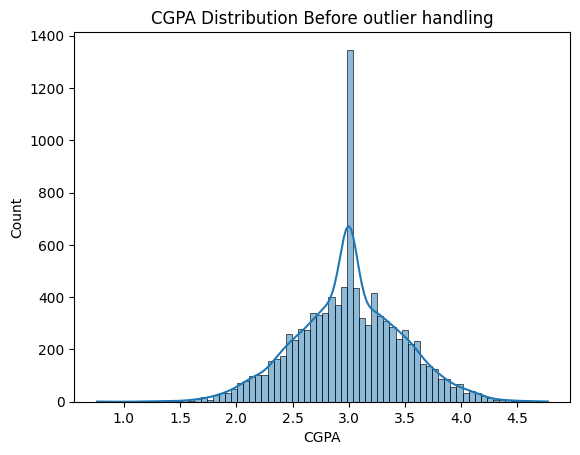

In [ ]:
# Histogram for CGPA before handling outliers
sns.histplot(df['CGPA'],kde=True)
plt.title('CGPA Distribution Before outlier handling')
plt.show()

##Handling CGPA Outliers Using Capping Method

Outliers capped successfully.


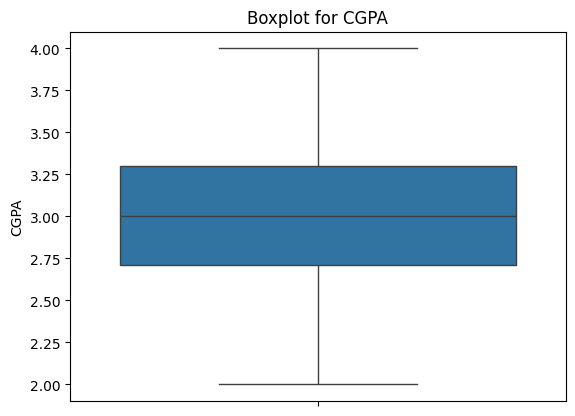

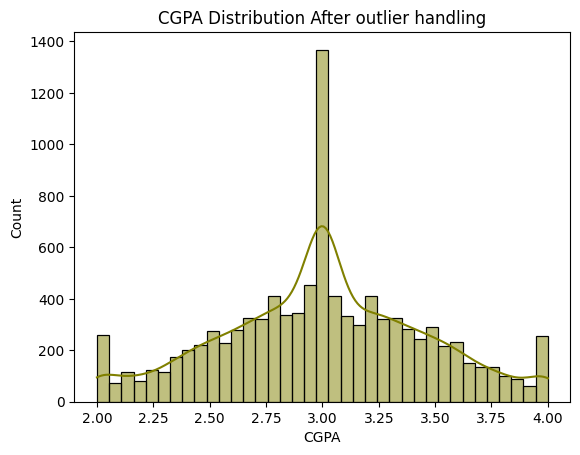

In [ ]:
# limit for CGPA
lower_limit = 2
upper_limit = 4

# Capping CGPA Outliers to Handle Extremes
df['CGPA'] = np.where(df['CGPA'] < lower_limit, lower_limit,np.where(df['CGPA'] > upper_limit, upper_limit, df['CGPA']))
print("Outliers capped successfully.")

#Boxplot after handling outliers
sns.boxplot(df['CGPA'])
plt.title('Boxplot for CGPA')
plt.show()

# Histogram for CGPA after handling outliers
sns.histplot(df['CGPA'],color='olive', kde=True)
plt.title('CGPA Distribution After outlier handling')
plt.show()

# Feature Engineering

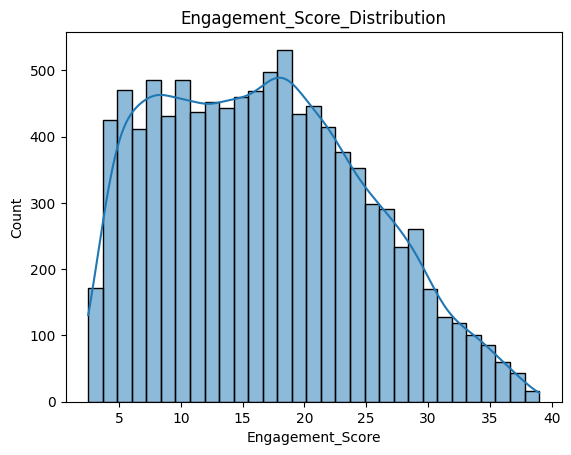

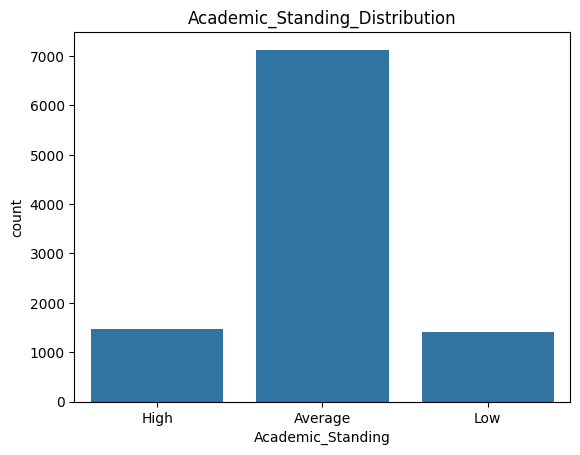

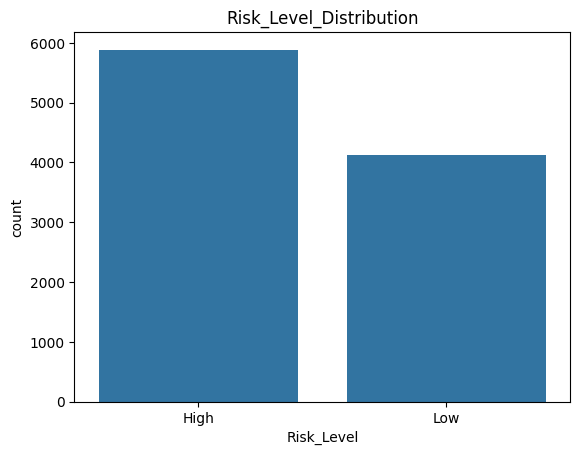

In [ ]:
# Create Engagement Score
df['Engagement_Score'] = df['Study_Hours_per_Week'] * df['Attendance_Percentage'] / 100

# Create Academic Standing
def academic_standing(cgpa):
    if cgpa < 2.5:
        return 'Low'
    elif 2.5 <= cgpa < 3.5:
        return 'Average'
    else:
        return 'High'

df['Academic_Standing'] = df['CGPA'].apply(academic_standing)

# Create Risk Level based on conditions
def risk_level(row):
    if row['Attendance_Percentage'] < 60 or row['Part_Time_Job'] == 'Yes' or row['Satisfaction_Level'] == 'Low':
        return 'High'
    return 'Low'

df['Risk_Level'] = df.apply(risk_level, axis=1)

# Visualize the new features
# Engagement Score
sns.histplot(df['Engagement_Score'], kde=True)
plt.title('Engagement_Score_Distribution')
plt.show()

# Academic Standing
sns.countplot(data=df, x='Academic_Standing')
plt.title('Academic_Standing_Distribution')
plt.show()

# Risk Level
sns.countplot(data=df, x='Risk_Level')
plt.title('Risk_Level_Distribution')
plt.show()


# Advanceed Data Manipulation

##Average CGPA by Department and Year of Study


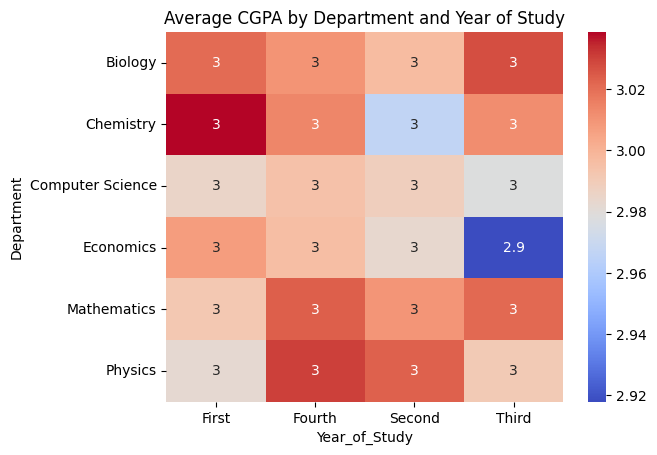

In [ ]:
# Pivot table to summarize average CGPA by Department and Year of Study
pivot_table = df.pivot_table(values='CGPA', index='Department', columns='Year_of_Study', aggfunc='mean')

# Visualize the pivot table as a heatmap
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title('Average CGPA by Department and Year of Study')
plt.show()

# Chemistry(2nd) & Economics(3rd) indicates dip in performance


##Analyzing Engagement Score Across Departments and Genders

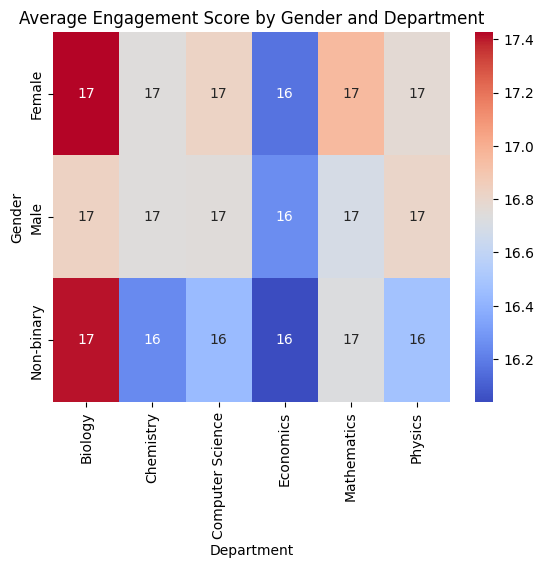

In [ ]:
# Groupby analysis of Engagement Score by Gender and Department
engagement_by_gender_dept = df.groupby(['Gender', 'Department'])['Engagement_Score'].mean().unstack()

# Visualize the Engagement Score using a heatmap
sns.heatmap(engagement_by_gender_dept, annot=True, cmap='coolwarm')
plt.title('Average Engagement Score by Gender and Department')
plt.show()


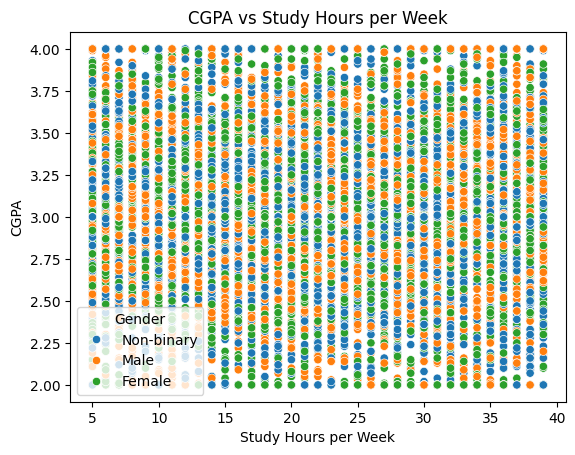

In [ ]:
# Scatter plot between CGPA and Study Hours per Week
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='CGPA', hue='Gender')
plt.title('CGPA vs Study Hours per Week')
plt.xlabel('Study Hours per Week')
plt.ylabel('CGPA')
plt.show()

In [ ]:
df.to_csv('cleaned_data.csv', index=False)